In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/features.csv')
print(df.shape)
print(df.dtypes)         # all features should be float64
print(df.isnull().sum())
print(df['mood'].value_counts())   # check class balance
df.head()

(999, 55)
filename          object
genre             object
mood              object
mfcc_mean_0      float64
mfcc_mean_1      float64
mfcc_mean_2      float64
mfcc_mean_3      float64
mfcc_mean_4      float64
mfcc_mean_5      float64
mfcc_mean_6      float64
mfcc_mean_7      float64
mfcc_mean_8      float64
mfcc_mean_9      float64
mfcc_mean_10     float64
mfcc_mean_11     float64
mfcc_mean_12     float64
mfcc_std_0       float64
mfcc_std_1       float64
mfcc_std_2       float64
mfcc_std_3       float64
mfcc_std_4       float64
mfcc_std_5       float64
mfcc_std_6       float64
mfcc_std_7       float64
mfcc_std_8       float64
mfcc_std_9       float64
mfcc_std_10      float64
mfcc_std_11      float64
mfcc_std_12      float64
chroma_0         float64
chroma_1         float64
chroma_2         float64
chroma_3         float64
chroma_4         float64
chroma_5         float64
chroma_6         float64
chroma_7         float64
chroma_8         float64
chroma_9         float64
chroma_10      

,filename,genre,mood,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,...,contrast_2,contrast_3,contrast_4,contrast_5,contrast_6,zcr_mean,zcr_std,rms_mean,rms_std,tempo
0,blues.00000.wav,blues,Sad,-113.619385,121.553017,-19.151058,42.345768,-6.371168,18.613033,-13.692060,...,18.458409,18.363125,18.918739,17.190236,39.667577,0.083066,0.027690,0.130192,0.053201,123.046875
1,blues.00001.wav,blues,Sad,-207.581512,123.997147,8.939115,35.870758,2.919971,21.518787,-8.555368,...,19.129324,19.187871,18.324039,17.504480,37.518985,0.056044,0.038059,0.095892,0.048724,67.999589
2,blues.00002.wav,blues,Sad,-90.776344,140.448608,-29.100559,31.687340,-13.975971,25.741682,-13.644712,...,17.706644,19.417250,20.344435,18.314965,39.035077,0.076301,0.031738,0.175494,0.052465,161.499023
3,blues.00003.wav,blues,Sad,-199.462006,150.094727,5.649167,26.870144,1.755441,14.236880,-4.828873,...,17.239784,18.636217,18.490758,16.790485,34.278016,0.033309,0.020569,0.141139,0.079623,63.024009
4,blues.00004.wav,blues,Sad,-160.291855,126.195770,-35.602501,22.151169,-32.487640,10.862022,-23.357162,...,19.125559,20.526383,20.785517,19.713927,37.338804,0.101500,0.044199,0.091540,0.048011,135.999178


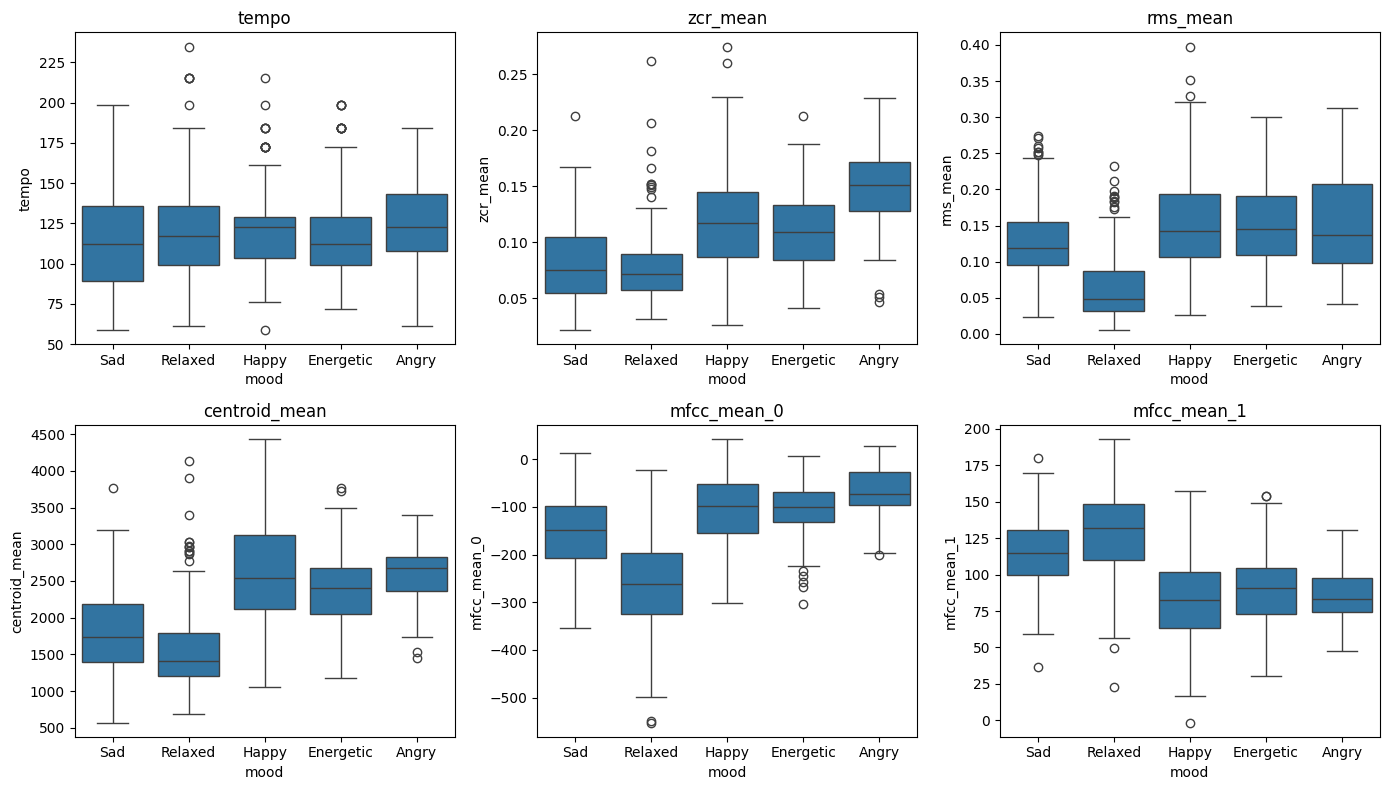

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['tempo','zcr_mean','rms_mean','centroid_mean',
            'mfcc_mean_0','mfcc_mean_1']
for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x='mood', y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout(); plt.show()

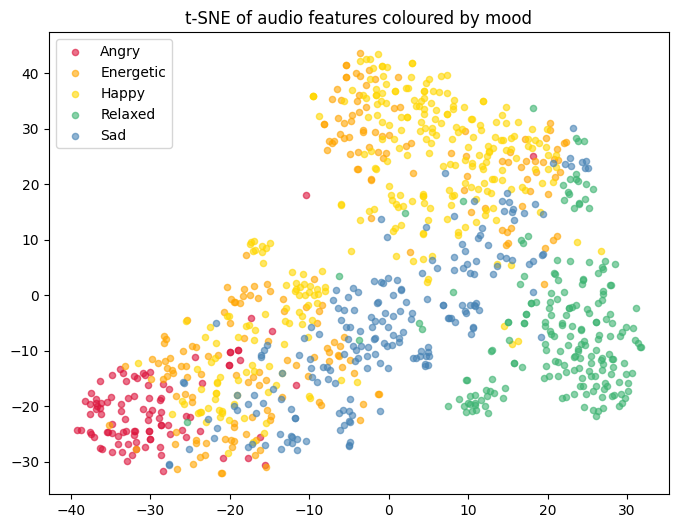

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

feat_cols = [c for c in df.columns if c not in
             ['filename','genre','mood']]
X = StandardScaler().fit_transform(df[feat_cols])
y = df['mood']

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X2 = tsne.fit_transform(X)

colors = {'Happy':'gold','Sad':'steelblue',
          'Angry':'crimson','Relaxed':'mediumseagreen',
          'Energetic':'orange'}
plt.figure(figsize=(8,6))
for mood, grp in df.assign(x=X2[:,0], y=X2[:,1]).groupby('mood'):
    plt.scatter(grp['x'], grp['y'], label=mood,
                c=colors.get(mood,'gray'), alpha=0.6, s=20)
plt.legend(); plt.title('t-SNE of audio features coloured by mood')
plt.show()